# 02. Sample 생성 & Brightness 분석
**담당자:** 주세원  
**목적:** 실험용 sample_200 생성 + 원본 vs 야간 밝기 히스토그램 시각화

---
**실행 순서**
1. Google Drive 마운트
2. sample_200 생성 (original + low_light + annotation)
3. 파일명 매칭 확인
4. Brightness Histogram 생성
5. Gamma 보정 전후 예시 이미지 저장

## Step 1. Google Drive 마운트

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

# 올바른 경로로 재설정
BASE_DIR    = '/content/drive/MyDrive/night-detection-project'
ORIG_DIR    = f'{BASE_DIR}/data/raw/coco/val2017'  # 수정된 부분
SYNTH_DIR   = f'{BASE_DIR}/data/synthetic/coco_gamma3.0'
ANNO_FILE   = f'{BASE_DIR}/data/raw/coco/annotations/instances_val2017.json'
SAMPLE_DIR  = f'{BASE_DIR}/data/sample_200'
RESULTS_DIR = f'{BASE_DIR}/results/analysis'

print(f'원본 이미지: {len(os.listdir(ORIG_DIR))}장')
print(f'야간 이미지: {len(os.listdir(SYNTH_DIR))}장')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
원본 이미지: 5000장
야간 이미지: 5000장


## Step 2. sample_200 생성

In [ ]:
import random
import shutil
import json

random.seed(42)  # 재현 가능하도록 seed 고정

SAMPLE_N = 200

# 원본 이미지 목록에서 무작위 200장 선택
all_images = sorted(os.listdir(ORIG_DIR))
sampled = random.sample(all_images, SAMPLE_N)
sampled_ids = set(os.path.splitext(f)[0] for f in sampled)  # 확장자 제거

print(f'선택된 샘플: {len(sampled)}장')
print(f'예시: {sampled[:3]}')

선택된 샘플: 200장
예시: ['000000107554.jpg', '000000021167.jpg', '000000260657.jpg']


In [8]:
# 원본 이미지 복사
missing_orig = []
for fname in sampled:
    src = os.path.join(ORIG_DIR, fname)
    dst = os.path.join(SAMPLE_DIR, 'original', fname)
    if os.path.exists(src):
        shutil.copy2(src, dst)
    else:
        missing_orig.append(fname)

print(f'✅ 원본 복사 완료: {SAMPLE_N - len(missing_orig)}장')
if missing_orig:
    print(f'⚠️  원본 누락: {missing_orig}')

✅ 원본 복사 완료: 200장


In [9]:
# 야간 이미지 복사 + 파일명 매칭 확인
missing_synth = []
for fname in sampled:
    src = os.path.join(SYNTH_DIR, fname)
    dst = os.path.join(SAMPLE_DIR, 'low_light_gamma3.0', fname)
    if os.path.exists(src):
        shutil.copy2(src, dst)
    else:
        missing_synth.append(fname)

print(f'✅ 야간 복사 완료: {SAMPLE_N - len(missing_synth)}장')
if missing_synth:
    print(f'⚠️  야간 누락 파일 ({len(missing_synth)}개): {missing_synth[:5]} ...')
else:
    print('✅ 파일명 매칭 100% 일치')

✅ 야간 복사 완료: 200장
✅ 파일명 매칭 100% 일치


In [10]:
# annotation 필터링 → annotations_sample_200.json 생성
with open(ANNO_FILE, 'r') as f:
    coco = json.load(f)

# 샘플 이미지에 해당하는 image id 추출
sampled_filenames = set(sampled)
sample_images = [img for img in coco['images'] if img['file_name'] in sampled_filenames]
sample_image_ids = set(img['id'] for img in sample_images)
sample_annos = [ann for ann in coco['annotations'] if ann['image_id'] in sample_image_ids]

sample_coco = {
    'info': coco.get('info', {}),
    'licenses': coco.get('licenses', []),
    'categories': coco['categories'],
    'images': sample_images,
    'annotations': sample_annos
}

anno_out = f'{SAMPLE_DIR}/annotations_sample_200.json'
with open(anno_out, 'w') as f:
    json.dump(sample_coco, f)

print(f'✅ annotations_sample_200.json 생성')
print(f'   이미지 수: {len(sample_images)}장')
print(f'   annotation 수: {len(sample_annos)}개')

✅ annotations_sample_200.json 생성
   이미지 수: 200장
   annotation 수: 1290개


## Step 3. 파일명 매칭 최종 확인

In [11]:
orig_files  = set(os.listdir(f'{SAMPLE_DIR}/original'))
synth_files = set(os.listdir(f'{SAMPLE_DIR}/low_light_gamma3.0'))

only_in_orig  = orig_files - synth_files
only_in_synth = synth_files - orig_files
matched = orig_files & synth_files

print(f'원본에만 있음: {len(only_in_orig)}개')
print(f'야간에만 있음: {len(only_in_synth)}개')
print(f'양쪽 모두 있음 (매칭): {len(matched)}개')

if len(only_in_orig) == 0 and len(only_in_synth) == 0:
    print('\n✅ 파일명 매칭 완벽! 실험 준비 완료')
else:
    print('\n⚠️  매칭 안 된 파일 있음 — 확인 필요')

원본에만 있음: 0개
야간에만 있음: 0개
양쪽 모두 있음 (매칭): 200개

✅ 파일명 매칭 완벽! 실험 준비 완료


## Step 4. Brightness Histogram 생성

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

HIST_SAMPLE_N = 50  # 히스토그램 계산에 사용할 이미지 수 (속도 조절)

orig_files_list  = sorted(os.listdir(f'{SAMPLE_DIR}/original'))[:HIST_SAMPLE_N]
synth_files_list = sorted(os.listdir(f'{SAMPLE_DIR}/low_light_gamma3.0'))[:HIST_SAMPLE_N]

orig_pixels  = []
synth_pixels = []

for fname in orig_files_list:
    img = cv2.imread(os.path.join(SAMPLE_DIR, 'original', fname))
    if img is not None:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        orig_pixels.extend(gray.flatten().tolist())

for fname in synth_files_list:
    img = cv2.imread(os.path.join(SAMPLE_DIR, 'low_light_gamma3.0', fname))
    if img is not None:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        synth_pixels.extend(gray.flatten().tolist())

orig_mean  = np.mean(orig_pixels)
synth_mean = np.mean(synth_pixels)

print(f'원본 평균 밝기:    {orig_mean:.1f}')
print(f'야간 합성 평균 밝기: {synth_mean:.1f}')
print(f'밝기 감소율:       {(1 - synth_mean/orig_mean)*100:.1f}%')

원본 평균 밝기:    118.1
야간 합성 평균 밝기: 55.1
밝기 감소율:       53.3%


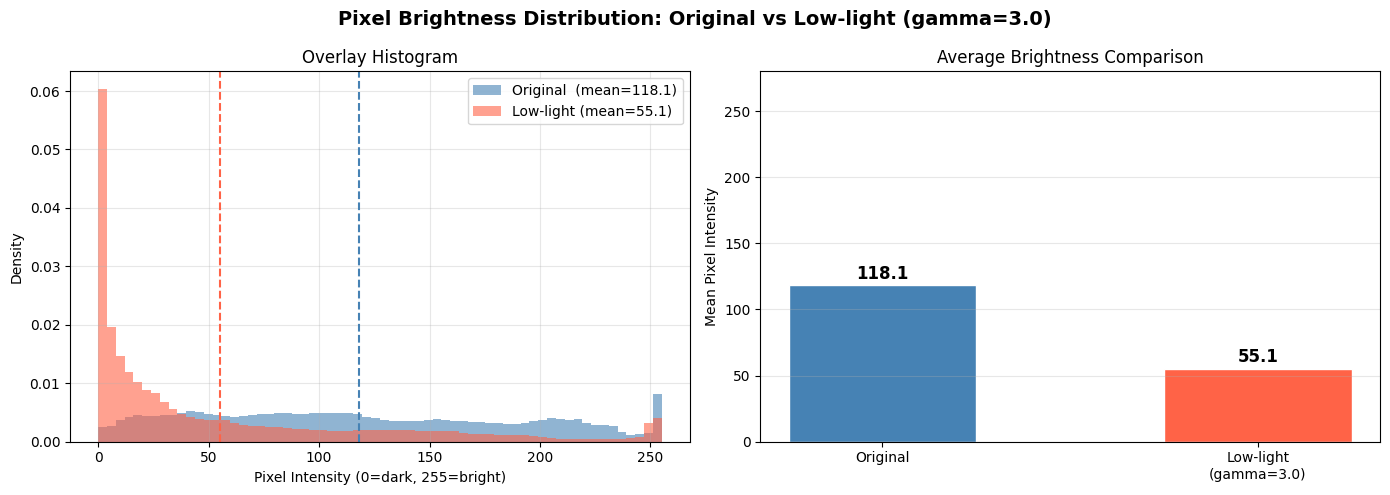


✅ 저장 완료: /content/drive/MyDrive/night-detection-project/results/analysis/brightness_histogram.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Pixel Brightness Distribution: Original vs Low-light (gamma=3.0)', fontsize=14, fontweight='bold')

# 왼쪽: 히스토그램 오버레이
ax = axes[0]
ax.hist(orig_pixels,  bins=64, range=(0,255), color='steelblue', alpha=0.6, label=f'Original  (mean={orig_mean:.1f})',  density=True)
ax.hist(synth_pixels, bins=64, range=(0,255), color='tomato',    alpha=0.6, label=f'Low-light (mean={synth_mean:.1f})', density=True)
ax.axvline(orig_mean,  color='steelblue', linestyle='--', linewidth=1.5)
ax.axvline(synth_mean, color='tomato',    linestyle='--', linewidth=1.5)
ax.set_xlabel('Pixel Intensity (0=dark, 255=bright)')
ax.set_ylabel('Density')
ax.set_title('Overlay Histogram')
ax.legend()
ax.grid(alpha=0.3)

# 오른쪽: 평균 밝기 바 차트
ax2 = axes[1]
bars = ax2.bar(['Original', 'Low-light\n(gamma=3.0)'],
               [orig_mean, synth_mean],
               color=['steelblue', 'tomato'], width=0.5, edgecolor='white')
for bar, val in zip(bars, [orig_mean, synth_mean]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             f'{val:.1f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax2.set_ylim(0, 280)
ax2.set_ylabel('Mean Pixel Intensity')
ax2.set_title('Average Brightness Comparison')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
out_path = f'{RESULTS_DIR}/brightness_histogram.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'\n✅ 저장 완료: {out_path}')

## Step 5. Gamma 보정 전후 예시 이미지 저장

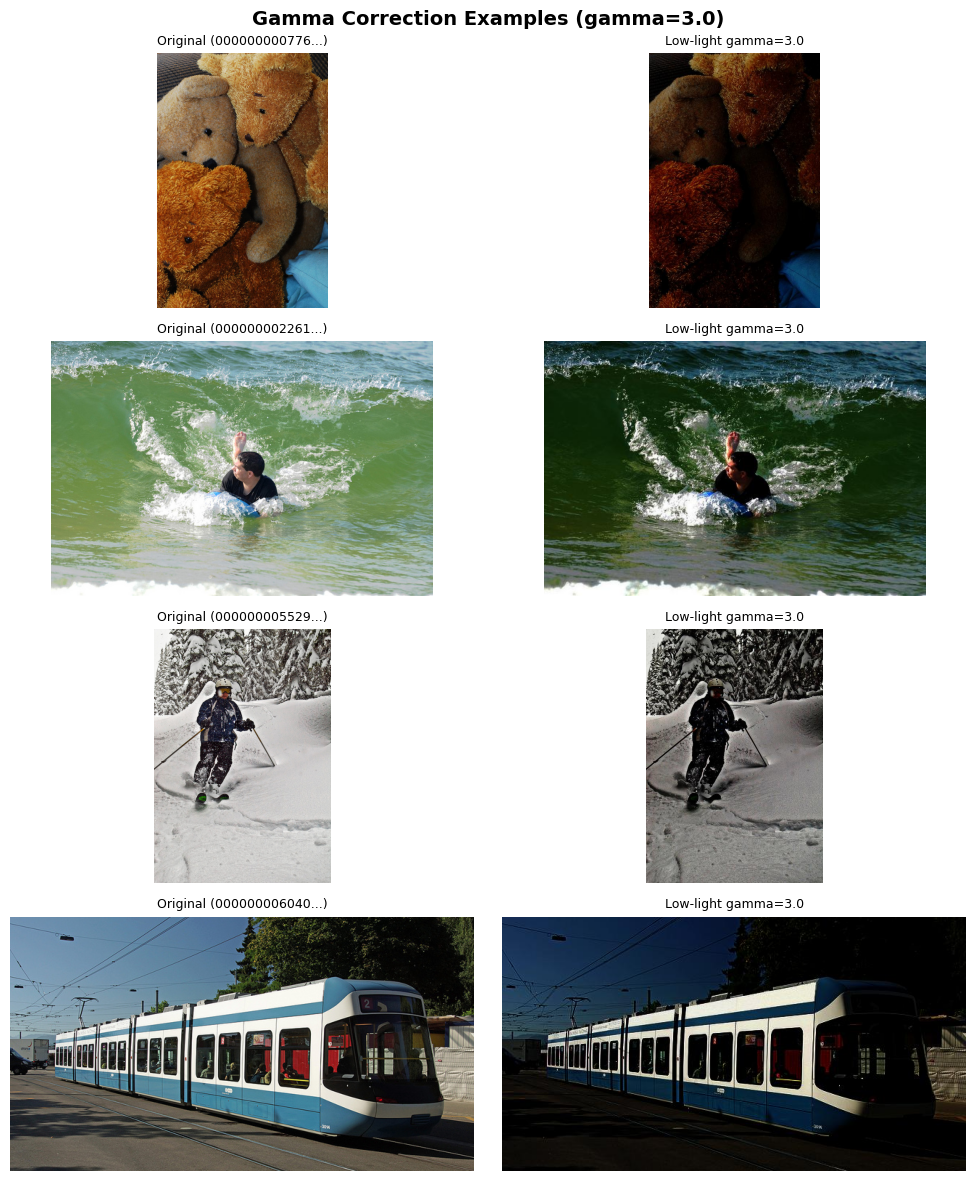


✅ 저장 완료: /content/drive/MyDrive/night-detection-project/results/analysis/gamma_comparison_samples.png


In [14]:
SHOW_N = 4  # 몇 장 보여줄지

sample_fnames = sorted(os.listdir(f'{SAMPLE_DIR}/original'))[:SHOW_N]

fig, axes = plt.subplots(SHOW_N, 2, figsize=(10, SHOW_N * 3))
fig.suptitle('Gamma Correction Examples (gamma=3.0)', fontsize=14, fontweight='bold')

for i, fname in enumerate(sample_fnames):
    orig_img  = cv2.imread(os.path.join(SAMPLE_DIR, 'original', fname))
    synth_img = cv2.imread(os.path.join(SAMPLE_DIR, 'low_light_gamma3.0', fname))

    orig_img  = cv2.cvtColor(orig_img,  cv2.COLOR_BGR2RGB)
    synth_img = cv2.cvtColor(synth_img, cv2.COLOR_BGR2RGB)

    axes[i][0].imshow(orig_img)
    axes[i][0].set_title(f'Original ({fname[:12]}...)', fontsize=9)
    axes[i][0].axis('off')

    axes[i][1].imshow(synth_img)
    axes[i][1].set_title(f'Low-light gamma=3.0', fontsize=9)
    axes[i][1].axis('off')

plt.tight_layout()
out_path2 = f'{RESULTS_DIR}/gamma_comparison_samples.png'
plt.savefig(out_path2, dpi=150, bbox_inches='tight')
plt.show()
print(f'\n✅ 저장 완료: {out_path2}')

## 최종 산출물 확인

In [15]:
checks = {
    'sample_200/original (200장)':              f'{SAMPLE_DIR}/original',
    'sample_200/low_light_gamma3.0 (200장)':    f'{SAMPLE_DIR}/low_light_gamma3.0',
    'annotations_sample_200.json':              f'{SAMPLE_DIR}/annotations_sample_200.json',
    'brightness_histogram.png':                 f'{RESULTS_DIR}/brightness_histogram.png',
    'gamma_comparison_samples.png':             f'{RESULTS_DIR}/gamma_comparison_samples.png',
}

print('=== 산출물 체크 ===')
for name, path in checks.items():
    if os.path.isdir(path):
        n = len(os.listdir(path))
        status = f'✅ {n}개 파일'
    elif os.path.isfile(path):
        status = '✅ 존재'
    else:
        status = '❌ 없음'
    print(f'{status:<15} {name}')

=== 산출물 체크 ===
✅ 200개 파일       sample_200/original (200장)
✅ 200개 파일       sample_200/low_light_gamma3.0 (200장)
✅ 존재            annotations_sample_200.json
✅ 존재            brightness_histogram.png
✅ 존재            gamma_comparison_samples.png
